In [1]:
entropy_ai_results = []
entropy_nai_results = [] 

ke_ai_results = []
ke_nai_results = []

In [24]:
# Import libraries
import numpy as np
import pickle

i = 9
n = str(i)
# load the saved embedding file
embedding_list_ai = []
with open('RAC_embed_ai_sample_'+ n +'.pkl','rb') as f:
    embedding_list_ai = pickle.load(f)

embedding_list_nai = []
with open('RAC_embed_nai_sample_'+ n +'.pkl','rb') as f:
    embedding_list_nai = pickle.load(f)

def entropy_cal(embedding_ai,embedding_nai):

    list_ai = np.array(embedding_ai)
    list_nai = np.array(embedding_nai)

    # ai entropy 
    ai_min_values = list_ai.min(axis=0)
    ai_max_values = list_ai.max(axis=0)

    ai_steps = (ai_max_values - ai_min_values) / 2

    ai_grid_indices = np.floor((list_ai - ai_min_values)/ai_steps).astype(int)
    ai_grid_indices = np.clip(ai_grid_indices,0,1)

    ai_grid_counts = {}
    for item in ai_grid_indices:
        ai_grid_tuple = tuple(item)
        if ai_grid_tuple not in ai_grid_counts:
            ai_grid_counts[ai_grid_tuple] = 0
        ai_grid_counts[ai_grid_tuple] += 1

    ai_total_points = len(list_ai)
    ai_p = np.array(list(ai_grid_counts.values())) / ai_total_points

    ai_entropy = -np.sum(ai_p * np.log(ai_p))
    print(ai_entropy,":knowledge entropy calculated based on embeddings of RAC AI papers.")

    # non-ai entropy
    nai_min_values = list_nai.min(axis=0)
    nai_max_values = list_nai.max(axis=0)

    nai_steps = (nai_max_values - nai_min_values) / 2

    nai_grid_indices = np.floor((list_nai - nai_min_values)/nai_steps).astype(int)
    nai_grid_indices = np.clip(nai_grid_indices,0,1)

    nai_grid_counts = {}
    for item in nai_grid_indices:
        nai_grid_tuple = tuple(item)
        if nai_grid_tuple not in nai_grid_counts:
            nai_grid_counts[nai_grid_tuple] = 0
        nai_grid_counts[nai_grid_tuple] += 1

    nai_total_points = len(list_nai)
    nai_p = np.array(list(nai_grid_counts.values())) / nai_total_points

    nai_entropy = -np.sum(nai_p * np.log(nai_p))
    print(nai_entropy,":knowledge entropy calculated based on embeddings of RAC non-AI papers.")

    return ai_entropy, nai_entropy

def extent_cal(embedding_ai, embedding_nai):
    list_ai = np.array(embedding_ai)
    list_nai = np.array(embedding_nai)
    
    size_ai = len(embedding_list_ai)
    size_nai = len(embedding_list_nai)

    c_ai = []
    c_nai = []
    
    for e in list_ai.transpose():
        ce = e.sum() / size_ai
        c_ai.append(ce)
    
    for en in list_nai.transpose():
        cen = en.sum() / size_nai
        c_nai.append(cen)
    
    cai = np.array(c_ai)
    cnai = np.array(c_nai)

    dist_ai = []
    dist_nai = []

    for item in list_ai:
        d = np.linalg.norm(item - cai)
        dist_ai.append(d)

    for item in list_nai:
        dn = np.linalg.norm(item - cnai)
        dist_nai.append(dn)
    
    ke_ai = max(dist_ai)
    ke_nai = max(dist_nai)
    
    print(ke_ai,":knowlege extent calcualted based on embeddings of RAC AI paper.")
    print(ke_nai,":knowlege extent calcualted based on embeddings of RAC non-AI paper.")

    return ke_ai, ke_nai

[entropy_ai,entropy_nai] = entropy_cal(embedding_list_ai,embedding_list_nai)
entropy_ai_results.append(entropy_ai)
entropy_nai_results.append(entropy_nai)

6.082546569677613 :knowledge entropy calculated based on embeddings of RAC AI papers.
6.191489880343354 :knowledge entropy calculated based on embeddings of RAC non-AI papers.


In [25]:
[keai,kenai] = extent_cal(embedding_list_ai,embedding_list_nai)
ke_ai_results.append(keai)
ke_nai_results.append(kenai)

1.4119395 :knowlege extent calcualted based on embeddings of RAC AI paper.
1.360842 :knowlege extent calcualted based on embeddings of RAC non-AI paper.


In [26]:
print(entropy_ai_results)
print(entropy_nai_results)
print(ke_ai_results)
print(ke_nai_results)

[np.float64(6.049420223763212), np.float64(6.121490691380712), np.float64(6.091928875413172), np.float64(6.083481266890406), np.float64(6.1235664723523895), np.float64(6.115580546790869), np.float64(6.080644580931667), np.float64(6.108621148765998), np.float64(6.048049883688616), np.float64(6.082546569677613)]
[np.float64(6.174330969807865), np.float64(6.067458346856213), np.float64(6.153453647453003), np.float64(6.112349007715943), np.float64(6.101531387849511), np.float64(6.090443213499347), np.float64(6.123946476689128), np.float64(6.057899034865766), np.float64(6.103028824292865), np.float64(6.191489880343354)]
[np.float32(1.4023768), np.float32(1.4202194), np.float32(1.4107149), np.float32(1.4207405), np.float32(1.4072725), np.float32(1.4260892), np.float32(1.3668331), np.float32(1.4294435), np.float32(1.4107089), np.float32(1.4119395)]
[np.float32(1.4922608), np.float32(1.4139297), np.float32(1.3870825), np.float32(1.4222298), np.float32(1.3849233), np.float32(1.3814784), np.floa

In [ ]:
with open('RAC_entropy_ai_result.pkl','wb') as file:
    pickle.dump(entropy_ai_results,file)
with open('RAC_entropy_nai_result.pkl','wb') as file:
    pickle.dump(entropy_nai_results,file)

with open('RAC_KE_ai_result.pkl','wb') as file:
    pickle.dump(ke_ai_results,file)
with open('RAC_KE_nai_result.pkl','wb') as file:
    pickle.dump(ke_nai_results,file)




In [2]:
import pickle

entropy_ai_results = []
entropy_nai_results = [] 

ke_ai_results = []
ke_nai_results = []

with open('RAC_entropy_ai_result.pkl','rb') as file:
    entropy_ai_results = pickle.load(file)
with open('RAC_entropy_nai_result.pkl','rb') as file:
    entropy_nai_results = pickle.load(file)

with open('RAC_KE_ai_result.pkl','rb') as file:
    ke_ai_results = pickle.load(file)
with open('RAC_KE_nai_result.pkl','rb') as file:
    ke_nai_results = pickle.load(file)


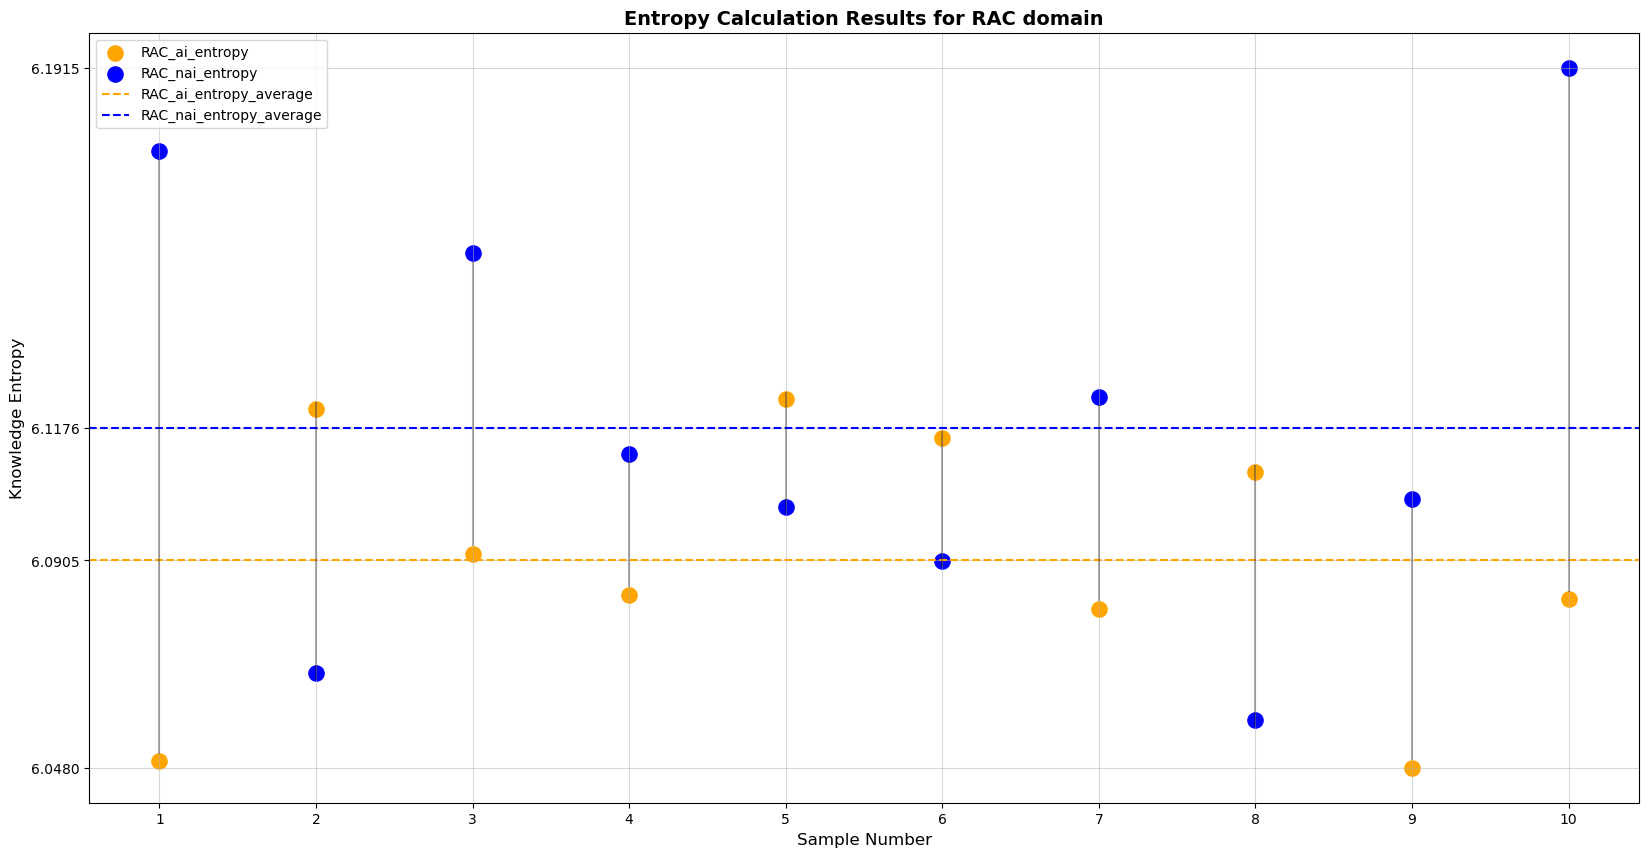

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

x = np.arange(1,11,1)
aver_ai = np.average(entropy_ai_results)
aver_nai = np.average(entropy_nai_results)
#median_ai = np.median(entropy_ai_results)
#median_nai = np.median(entropy_nai_results)
#print(median_ai)
#print(median_nai)

plt.figure(figsize=(20, 10))
plt.scatter(x,entropy_ai_results,label='RAC_ai_entropy',s=120,alpha=1,color='orange')
plt.scatter(x,entropy_nai_results,label='RAC_nai_entropy',s=120,alpha=1,color='blue')
plt.axhline(y=aver_ai,label='RAC_ai_entropy_average',linestyle='--',color='orange')
plt.axhline(y=aver_nai,label='RAC_nai_entropy_average',linestyle='--',color='blue')

#plt.axhline(y=median_ai,label='HEA_ai_entropy_median',linestyle='-',color='orange')
#plt.axhline(y=median_nai,label='HEA_ai_entropy_median',linestyle='-',color='blue')

min_e = np.subtract(entropy_ai_results,-0.0015)
max_e = np.subtract(entropy_nai_results,0.0015)
plt.vlines(x,ymin=min_e,ymax=max_e,colors='k',alpha=0.3)
plt.grid(True,alpha=0.5)

plt.xticks(x)
plt.yticks([min(entropy_ai_results),aver_ai,aver_nai,max(entropy_nai_results)])
plt.xlabel('Sample Number',fontsize=12)
plt.ylabel('Knowledge Entropy',fontsize=12)
plt.title('Entropy Calculation Results for RAC domain', fontsize=14, fontweight='bold')

plt.legend()
plt.show()


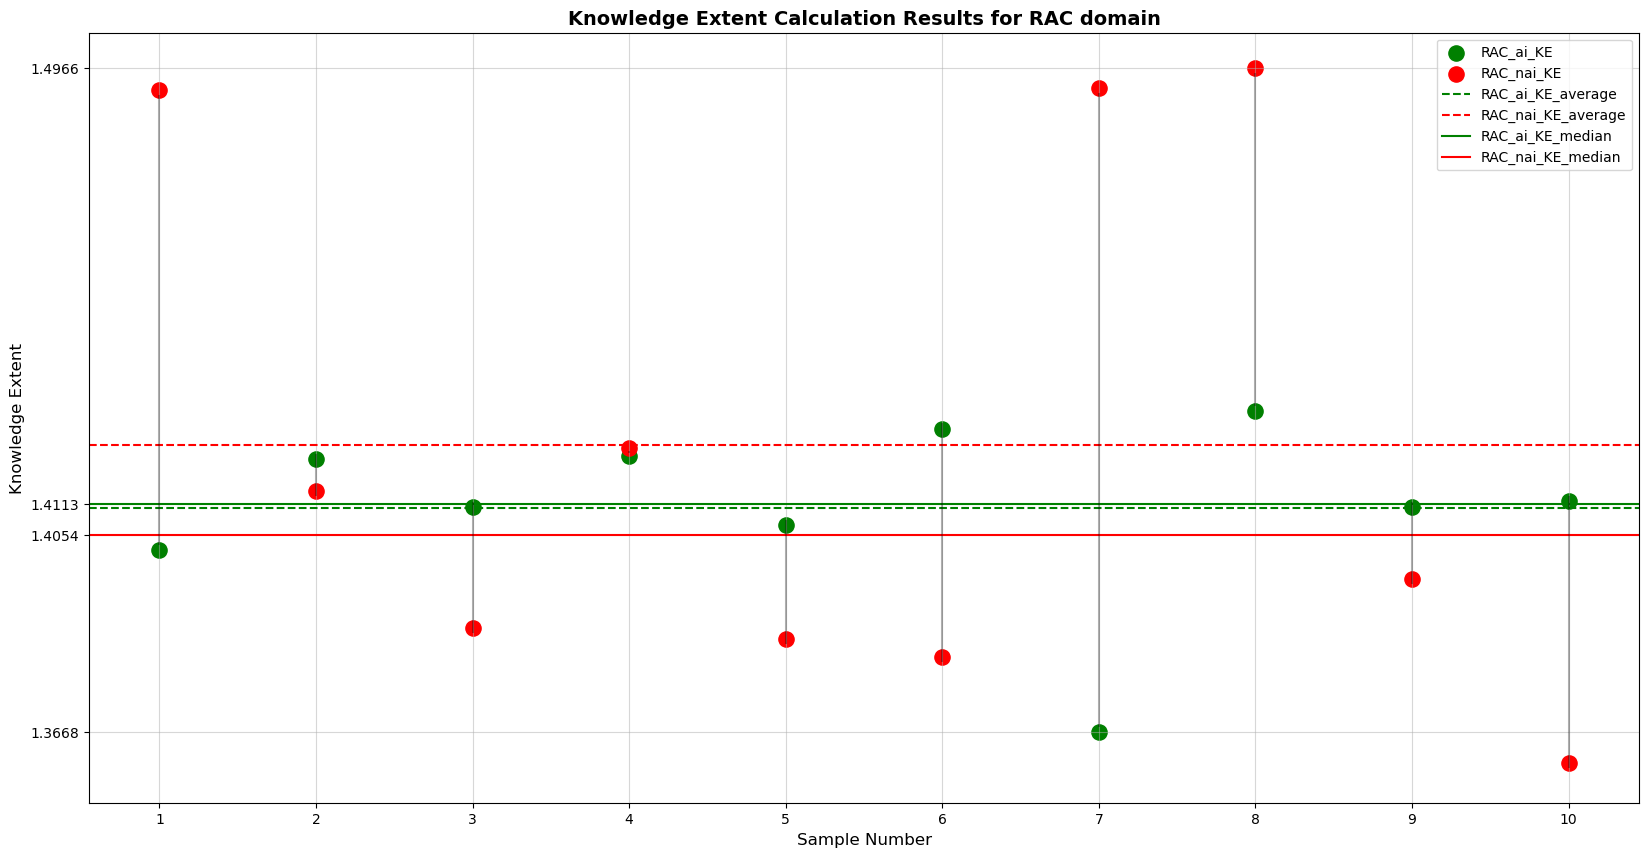

In [8]:
aver_ke_ai = np.average(ke_ai_results)
aver_ke_nai = np.average(ke_nai_results)
median_ke_ai = np.median(ke_ai_results)
median_ke_nai = np.median(ke_nai_results)
#print(aver_ke_ai)
#print(aver_ke_nai)

plt.figure(figsize=(20, 10))
plt.scatter(x,ke_ai_results,label='RAC_ai_KE',s=120,alpha=1,color='g')
plt.scatter(x,ke_nai_results,label='RAC_nai_KE',s=120,alpha=1,color='r')
plt.axhline(y=aver_ke_ai,label='RAC_ai_KE_average',linestyle='--',color='g')
plt.axhline(y=aver_ke_nai,label='RAC_nai_KE_average',linestyle='--',color='r')

plt.axhline(y=median_ke_ai,label='RAC_ai_KE_median',linestyle='-',color='g')
plt.axhline(y=median_ke_nai,label='RAC_nai_KE_median',linestyle='-',color='r')

min_e = np.subtract(ke_ai_results,-0.001)
max_e = np.subtract(ke_nai_results,0.001)
plt.vlines(x,ymin=min_e,ymax=max_e,colors='k',alpha=0.3)
plt.grid(True,alpha=0.5)

plt.xticks(x)
plt.yticks([min(ke_ai_results),median_ke_nai,median_ke_ai,max(ke_nai_results)])
plt.xlabel('Sample Number',fontsize=12)
plt.ylabel('Knowledge Extent',fontsize=12)
plt.title('Knowledge Extent Calculation Results for RAC domain', fontsize=14, fontweight='bold')

plt.legend()
plt.show()